### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

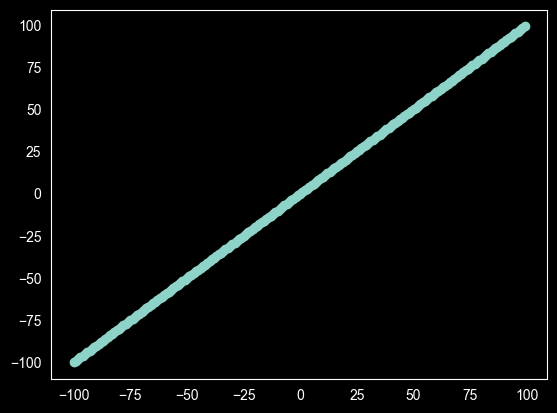

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

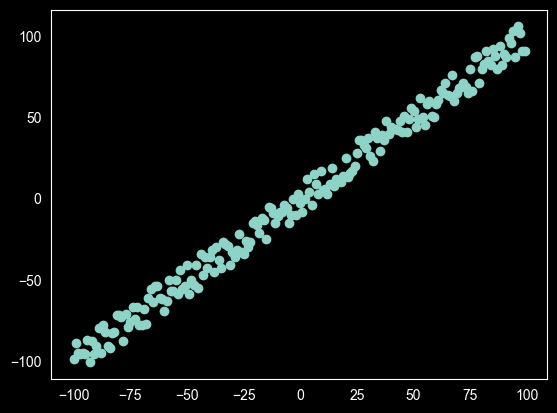

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

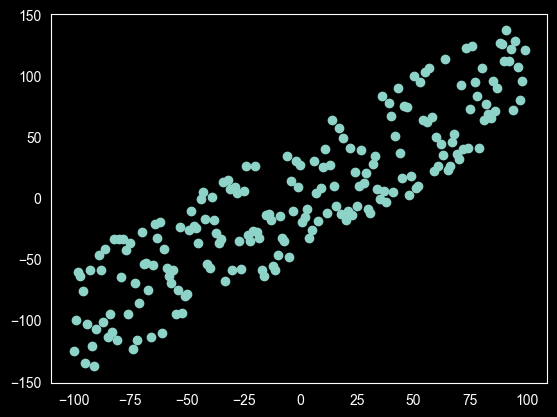

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

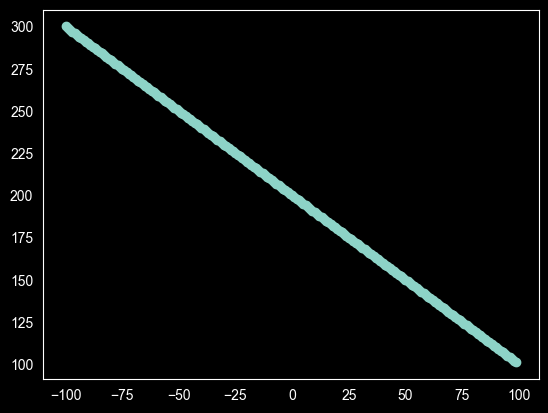

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

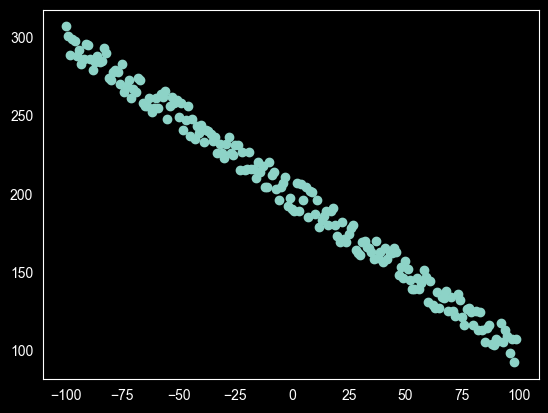

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

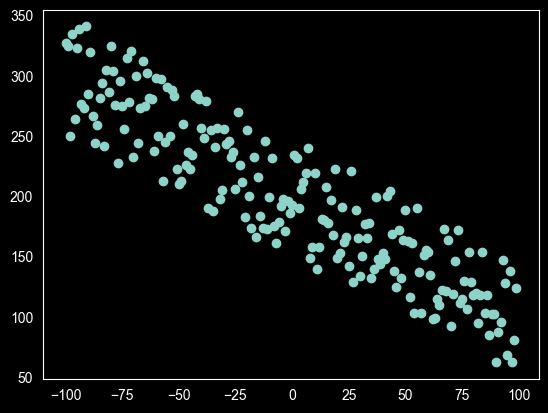

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

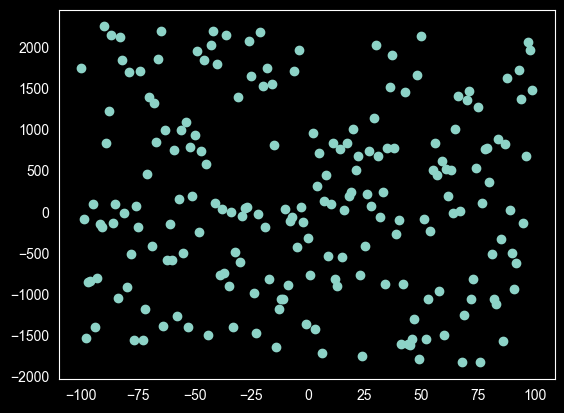

In [8]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Metrics

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    try:
        return round(mse, 4)
    except Exception:
        return mse

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    try:
        return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)
    except Exception:
        return 1 - sum((y-y_pred)**2)/sum((y-y_mean)**2)


### Solve by Normal Equation

In [12]:
def solve_by_norm_eq(x, y):
    x_b = np.array([[1, i] for i in x])
    c, m = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 1.0   y-Intercept : -0.0   MSE : 0.0   R2 : 1.0


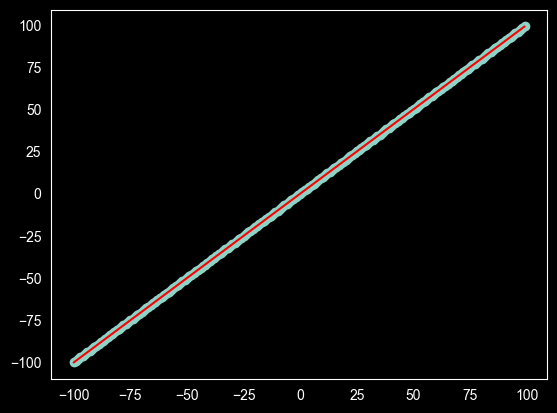

In [13]:
# Solve for Data 1
solve_by_norm_eq(x1, y1)

Slope : 0.9957   y-Intercept : -0.0122   MSE : 36.4173   R2 : 0.9891


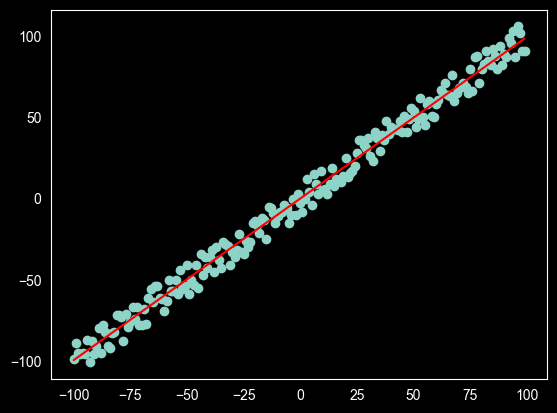

In [14]:
# Solve for Data 2
solve_by_norm_eq(x2, y2)

Slope : 0.9764   y-Intercept : 0.0132   MSE : 904.5366   R2 : 0.7784


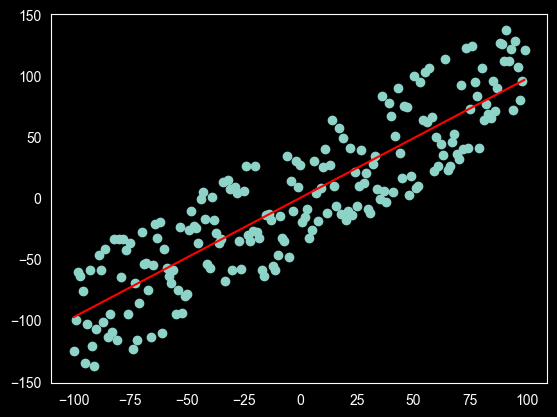

In [15]:
# Solve for Data 3
solve_by_norm_eq(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


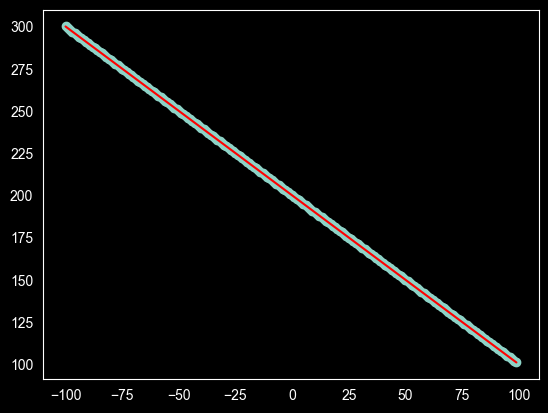

In [16]:
# Solve for Data 4
solve_by_norm_eq(x4, y4)

Slope : -0.9979   y-Intercept : 199.566   MSE : 36.8914   R2 : 0.989


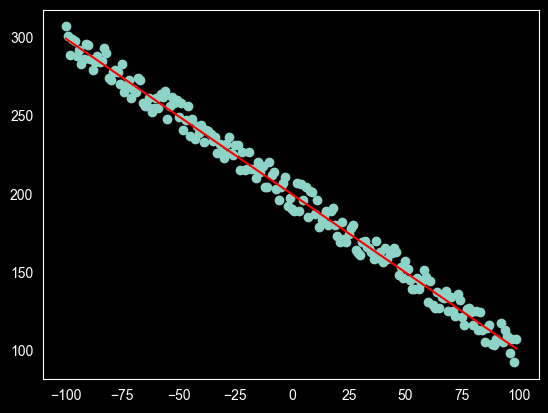

In [17]:
# Solve for Data 5
solve_by_norm_eq(x5, y5)

Slope : -1.0493   y-Intercept : 199.2154   MSE : 775.9663   R2 : 0.8255


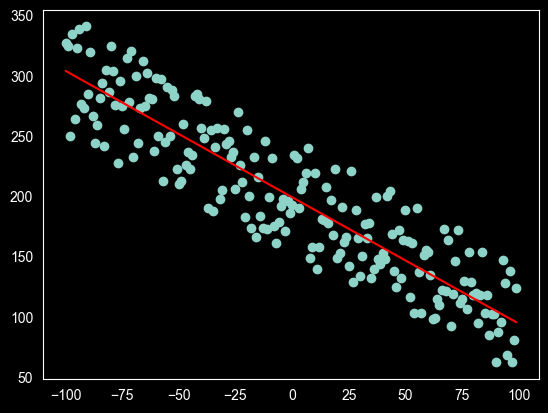

In [18]:
# Solve for Data 6
solve_by_norm_eq(x6, y6)

Slope : -0.7259   y-Intercept : 151.2271   MSE : 1244991.7596   R2 : 0.0014


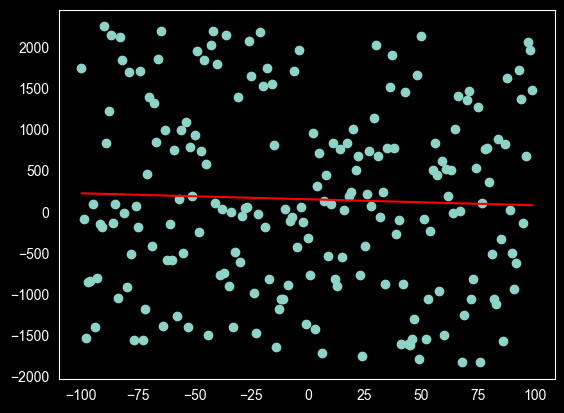

In [19]:
# Solve for Data 7
solve_by_norm_eq(x7, y7)

### Solve by SVD

In [20]:
def solve_by_svd(x, y):
    X = np.c_[np.ones(len(x)), x]
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    S_inv = np.diag(1 / S)
    theta = Vt.T @ S_inv @ U.T @ y
    c, m = theta[0], theta[1]
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


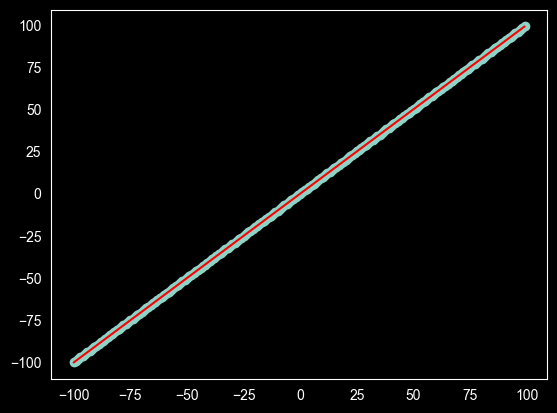

In [21]:
# Solve for Data 1
solve_by_svd(x1, y1)

Slope : 0.9957   y-Intercept : -0.0122   MSE : 36.4173   R2 : 0.9891


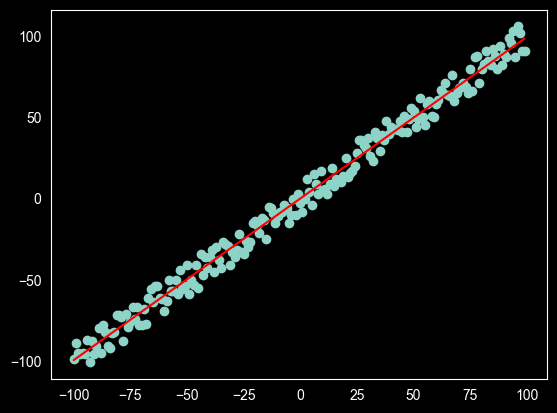

In [22]:
# Solve for Data 2
solve_by_svd(x2, y2)

Slope : 0.9764   y-Intercept : 0.0132   MSE : 904.5366   R2 : 0.7784


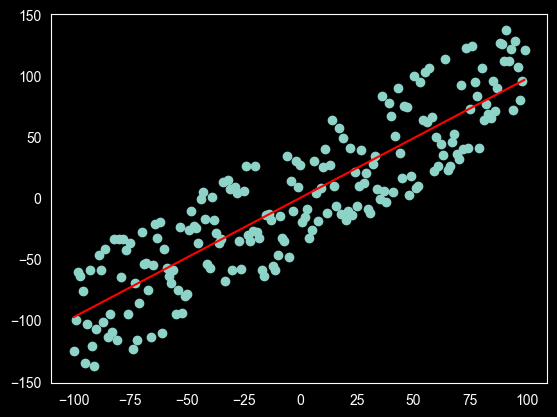

In [23]:
# Solve for Data 3
solve_by_svd(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


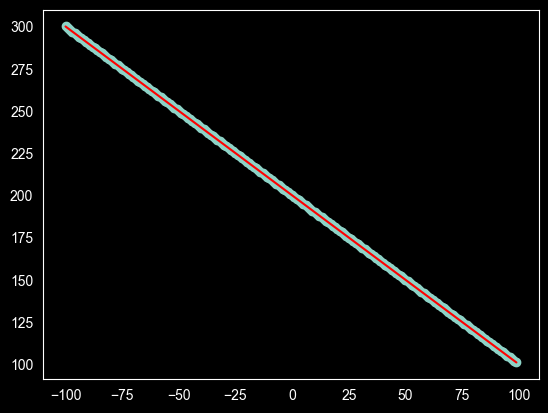

In [24]:
# Solve for Data 4
solve_by_svd(x4, y4)

Slope : -0.9979   y-Intercept : 199.566   MSE : 36.8914   R2 : 0.989


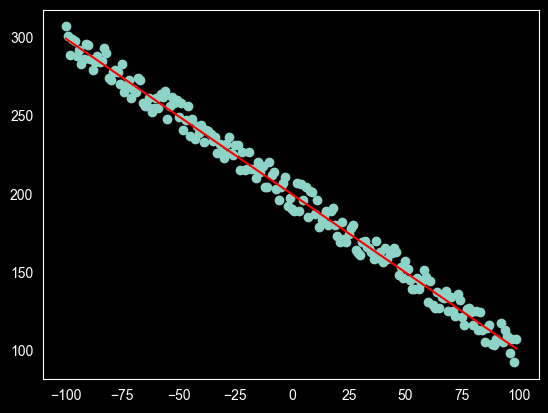

In [25]:
# Solve for Data 5
solve_by_svd(x5, y5)

Slope : -1.0493   y-Intercept : 199.2154   MSE : 775.9663   R2 : 0.8255


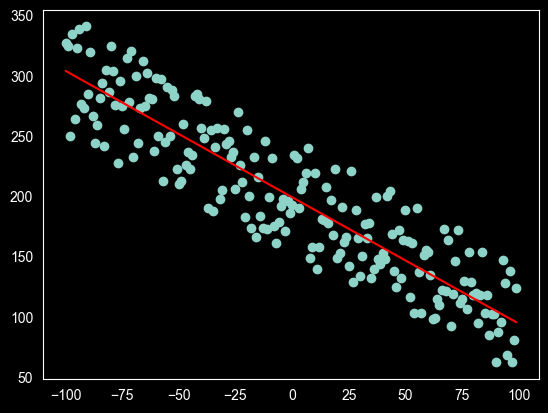

In [26]:
# Solve for Data 6
solve_by_svd(x6, y6)

Slope : -0.7259   y-Intercept : 151.2271   MSE : 1244991.7596   R2 : 0.0014


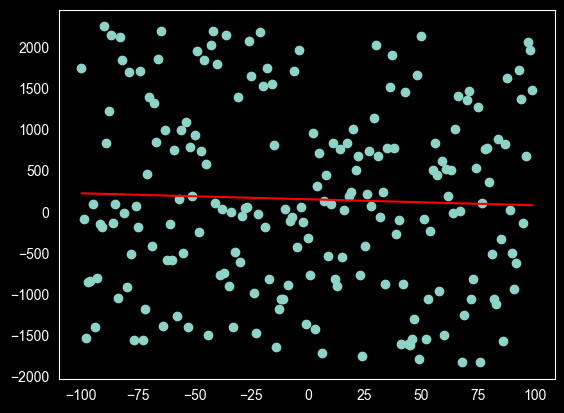

In [27]:
# Solve for Data 7
solve_by_svd(x7, y7)

### Solve by Grid Search

In [56]:
def solve_by_grid_search(x, y):
    best_b0 = None
    best_b1 = None
    best_mse = float("inf")
    for b0 in range(-1000, 1001):
        for b1 in range(-10, 11):
            predictions = []
            for xi in x:
                y_hat = b0 + b1 * xi
                predictions.append(y_hat)
            squared_errors = []
            for yi, y_hat in zip(y, predictions):
                squared_errors.append((yi - y_hat) ** 2)
            mse_ = sum(squared_errors) / len(y)
            if mse_ < best_mse:
                best_mse = mse_
                best_b0 = b0
                best_b1 = b1
    c = best_b0
    m = best_b1
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 1   y-Intercept : 0   MSE : 0.0   R2 : 1.0


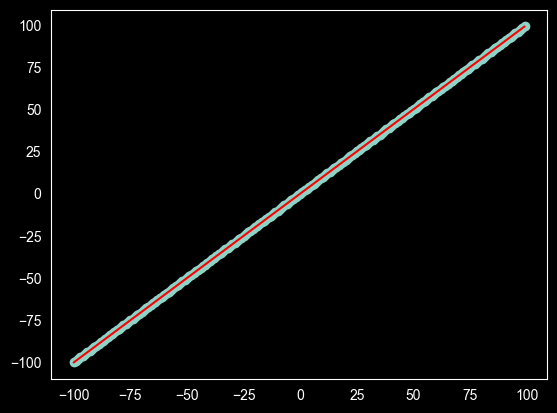

In [57]:
# Solve for Data 1
solve_by_grid_search(x1, y1)

Slope : 1   y-Intercept : 0   MSE : 36.48   R2 : 0.9891


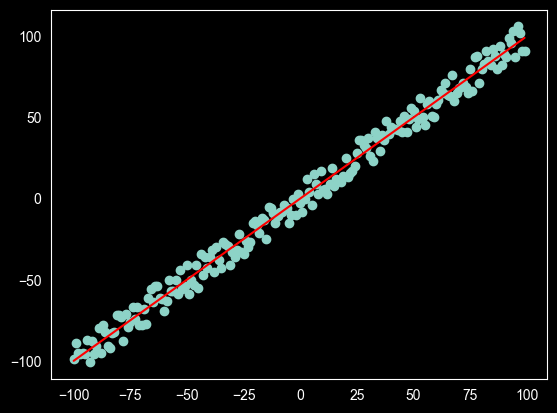

In [58]:
# Solve for Data 2
solve_by_grid_search(x2, y2)

Slope : 1   y-Intercept : 0   MSE : 906.395   R2 : 0.778


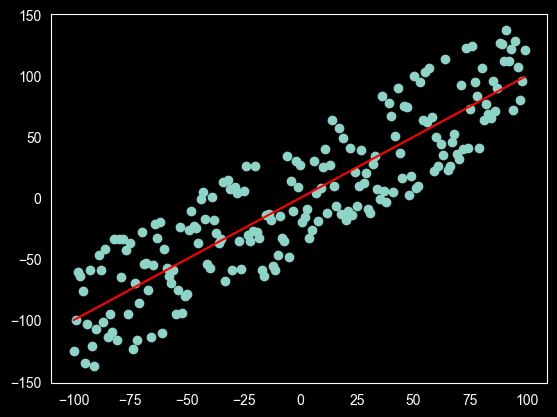

In [59]:
# Solve for Data 3
solve_by_grid_search(x3, y3)

Slope : -1   y-Intercept : 200   MSE : 0.0   R2 : 1.0


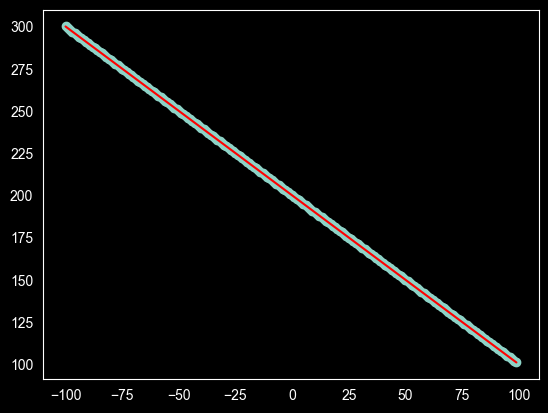

In [60]:
# Solve for Data 4
solve_by_grid_search(x4, y4)

Slope : -1   y-Intercept : 200   MSE : 37.095   R2 : 0.9889


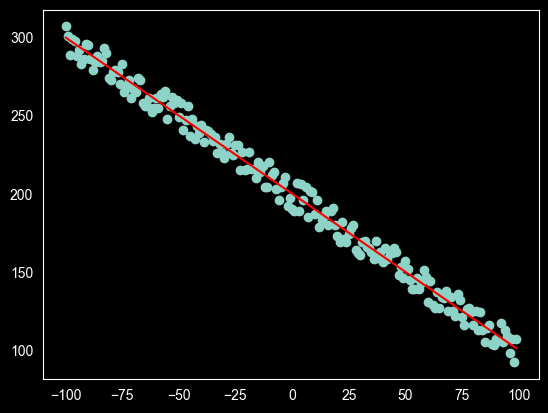

In [71]:
# Solve for Data 5
solve_by_grid_search(x5, y5)

Slope : -1   y-Intercept : 199   MSE : 784.12   R2 : 0.8236


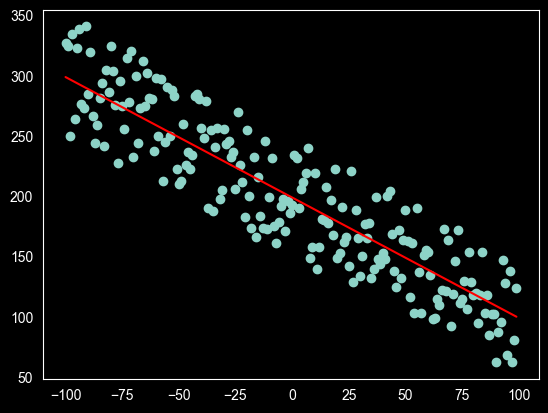

In [72]:
# Solve for Data 6
solve_by_grid_search(x6, y6)

Slope : -1   y-Intercept : 151   MSE : 1245242.22   R2 : 0.0012


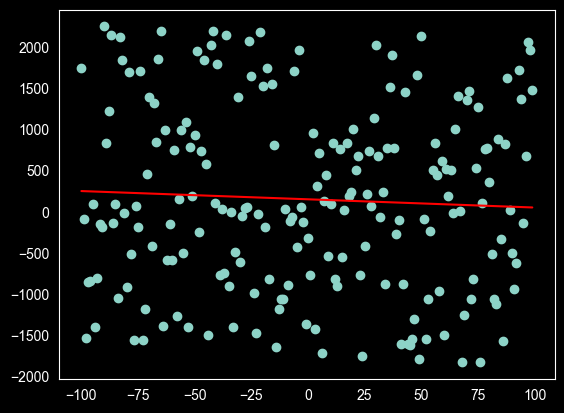

In [73]:
# Solve for Data 7
solve_by_grid_search(x7, y7)

### Solve by Gradient Descent

In [30]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1):
    x_scaled = (x-x.mean())/x.std()
    y_scaled = (y-y.mean())/y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    m = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / m * x_b.T @ (x_b @ theta - y_scaled)
        theta = theta - eta * gradients
    c, m = round(theta[0][0], 4), round(theta[-1][0], 4)
    m = m * y.std() / x.std()
    c = c * y.std() + y.mean() - m * x.mean()
    y_pred = predict(x, m, c)
    MSE = round(mse(y, y_pred.reshape(-1, 1))[0], 4)
    R2 = round(r2(y, y_pred.reshape(-1, 1))[0], 4)
    print(f"Slope :", m, "  y-Intercept :", c, "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 1.0   y-Intercept : 0.0   MSE : 13233.5   R2 : -2.9701


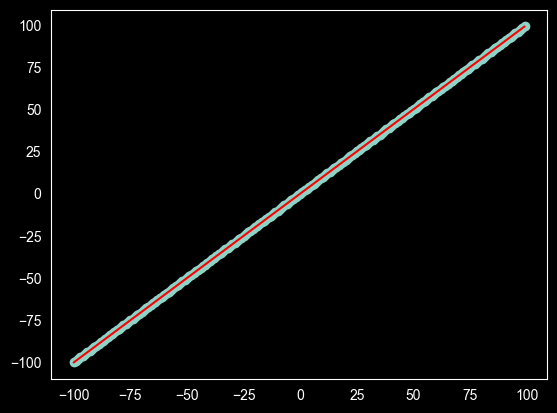

In [31]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

Slope : 0.9956316078297008   y-Intercept : -0.01218419608514959   MSE : 13004.4718   R2 : -2.8926


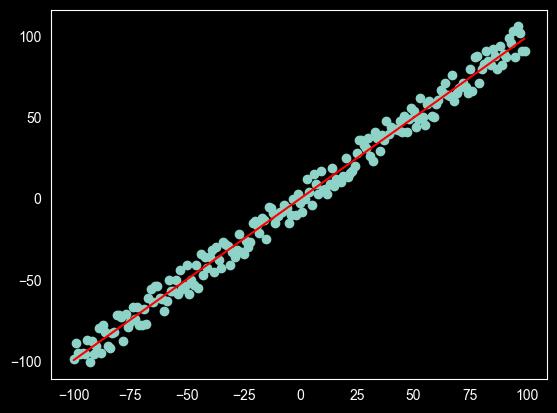

In [32]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

Slope : 0.9764109313133984   y-Intercept : 0.013205465656699222   MSE : 18684.3239   R2 : -3.577


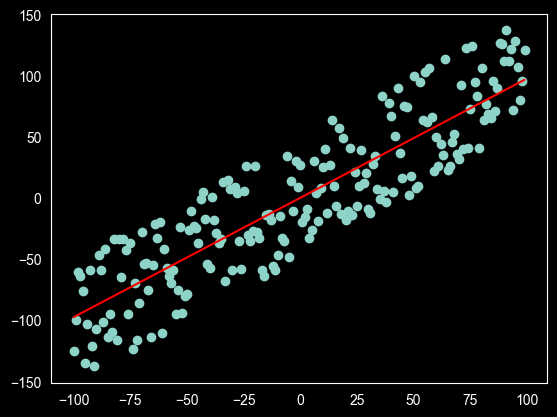

In [33]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 13233.5   R2 : -2.9701


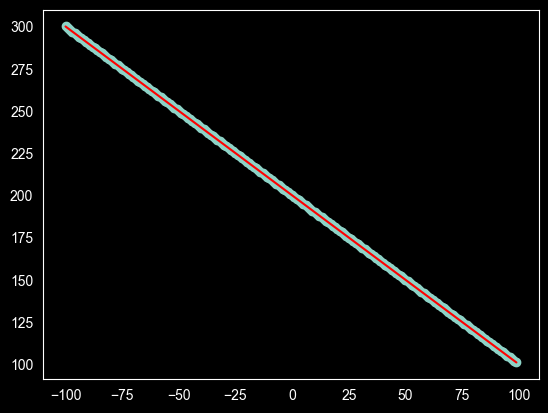

In [34]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

Slope : -0.9979342474741711   y-Intercept : 199.5660328762629   MSE : 14754.5871   R2 : -3.3961


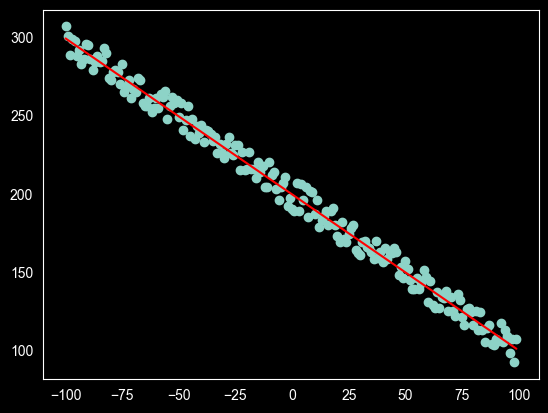

In [35]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

Slope : -1.049341374822109   y-Intercept : 199.21532931258895   MSE : 19865.4069   R2 : -3.4683


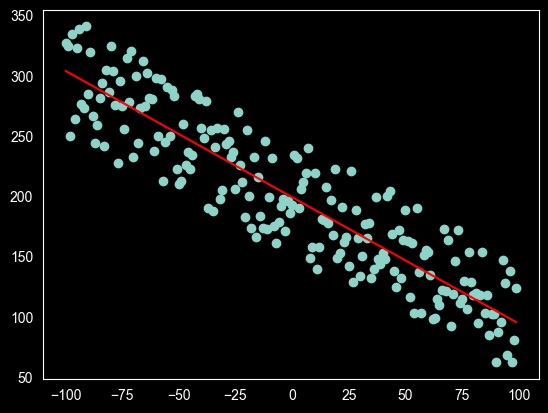

In [36]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

Slope : -0.7252482339829134   y-Intercept : 151.22737588300853   MSE : 2531157.2076   R2 : -1.0302


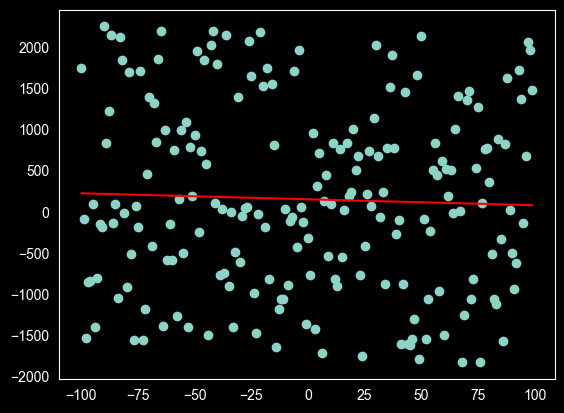

In [37]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [62]:
from sklearn.linear_model import LinearRegression

def get_model(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [63]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()


Slope : [1.]   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


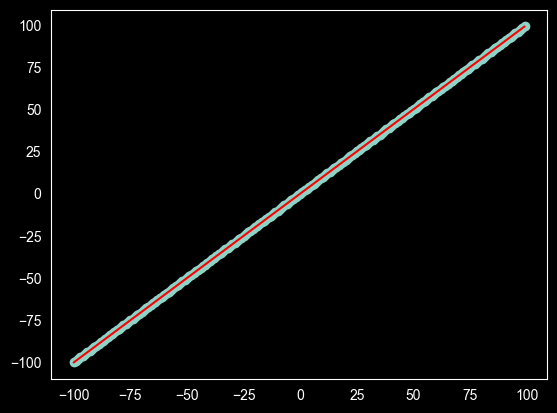

In [64]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

Slope : [0.99566639]   y-Intercept : -0.0122   MSE : 36.41730102752569   R2 : 0.9890993576113822


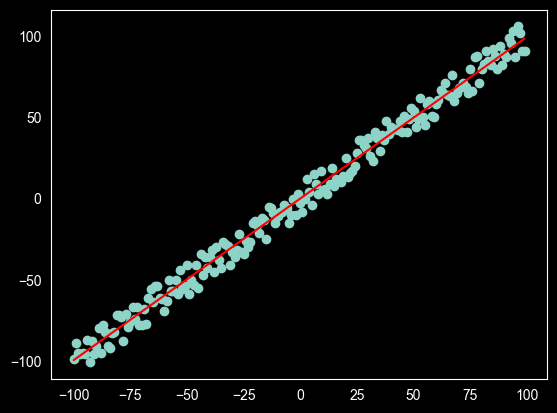

In [65]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

Slope : [0.97639166]   y-Intercept : 0.0132   MSE : 904.5365756881422   R2 : 0.7784225614796605


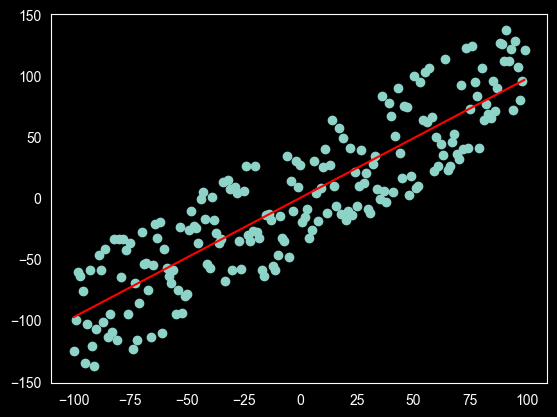

In [66]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

Slope : [-1.]   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


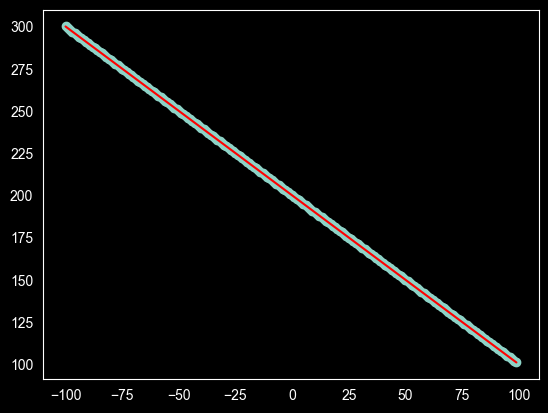

In [67]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

Slope : [-0.9979232]   y-Intercept : 199.566   MSE : 36.89139833870847   R2 : 0.9890083485076829


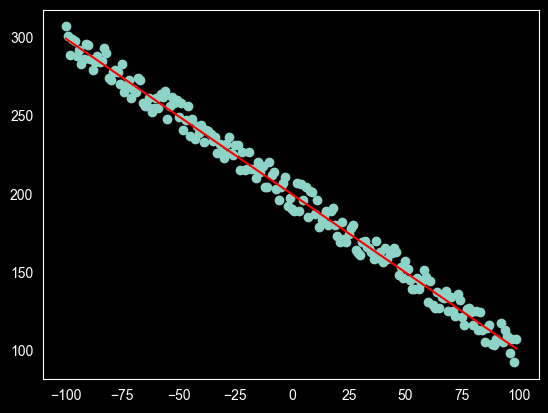

In [68]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

Slope : [-1.04928373]   y-Intercept : 199.2154   MSE : 775.966314910373   R2 : 0.8254632633456283


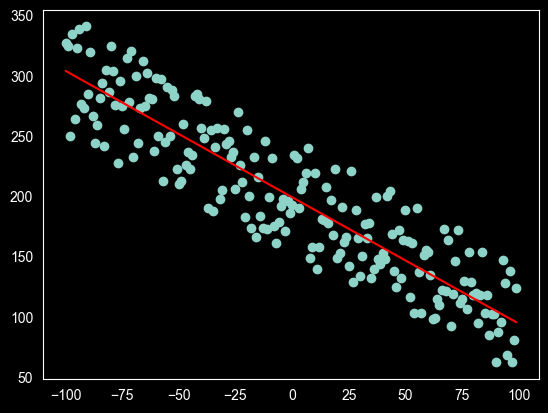

In [69]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

Slope : [-0.72588765]   y-Intercept : 151.2271   MSE : 1244991.759554924   R2 : 0.001408730726348617


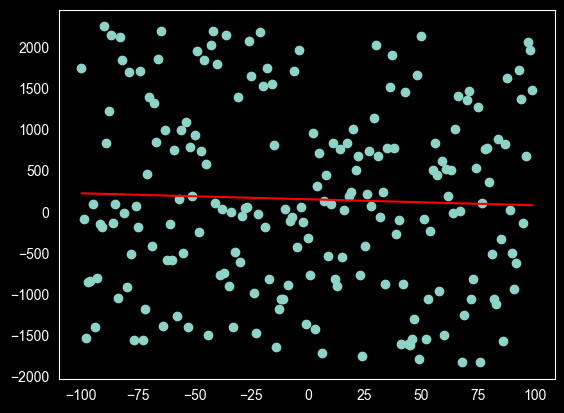

In [70]:
# Solve for Data 7
solve_by_sklearn(x7, y7)